In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"Agriculture_pricet.csv")
display(df.head())

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [3]:
df['Price Date'] = pd.to_datetime(df['Price Date'])
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month

In [4]:
print(df.isna().sum())
print(df.duplicated().sum())

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
Year             0
Month            0
dtype: int64
0


In [5]:
print(df.shape)   # rows, columns
print(df.columns)
print(df.dtypes)
display(df.head())

(737392, 12)
Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date', 'Year',
       'Month'],
      dtype='object')
STATE                    object
District Name            object
Market Name              object
Commodity                object
Variety                  object
Grade                    object
Min_Price               float64
Max_Price               float64
Modal_Price             float64
Price Date       datetime64[ns]
Year                      int32
Month                     int32
dtype: object


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date,Year,Month
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,2023-06-06,2023,6
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,2023-06-06,2023,6
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,2023-06-06,2023,6
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,2023-06-06,2023,6
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,2023-06-06,2023,6


In [6]:
print(df.isnull().sum())
df.dropna(how="all", inplace=True)

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
Year             0
Month            0
dtype: int64


In [7]:
categorical_cols = ['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert to string to avoid errors with NaNs
    label_encoders[col] = le  

In [8]:
scaler = StandardScaler()
num_cols = ['Min_Price', 'Max_Price']
df[num_cols] = scaler.fit_transform(df[num_cols])

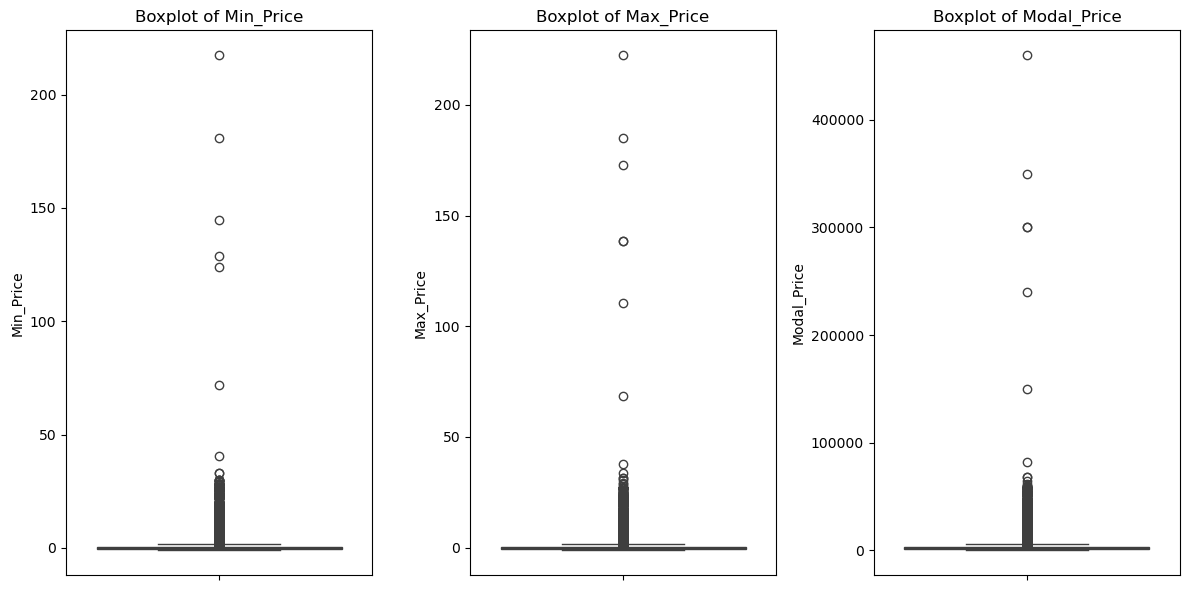

In [13]:
price_cols = ['Min_Price', 'Max_Price', 'Modal_Price']

plt.figure(figsize=(12,6))

for i, col in enumerate(price_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [20]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


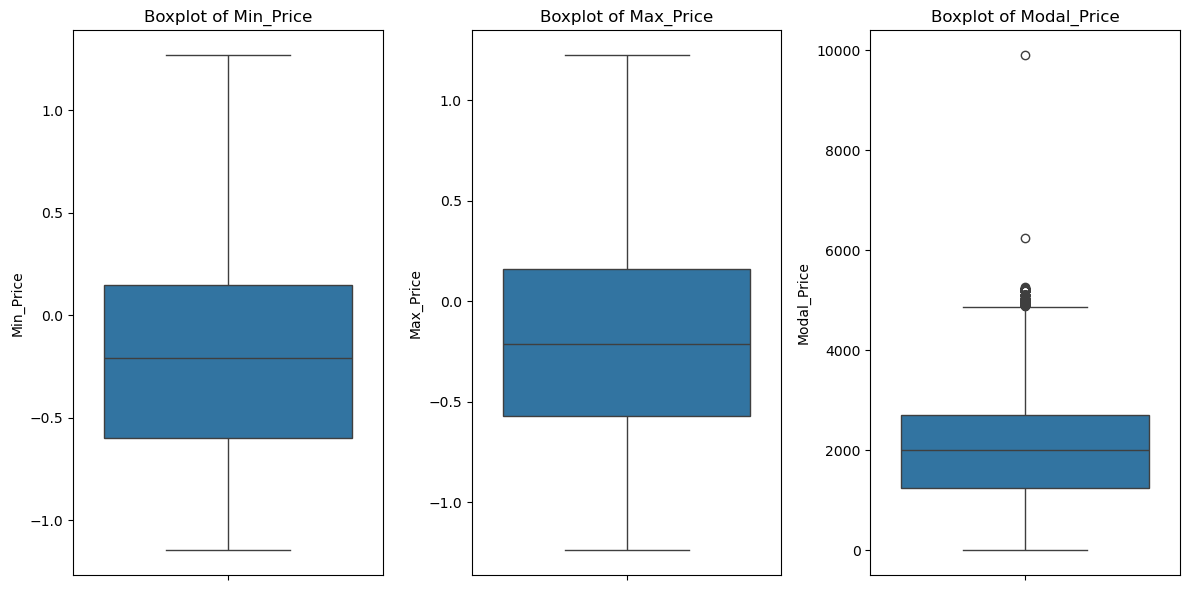

In [21]:
price_cols = ['Min_Price', 'Max_Price', 'Modal_Price']

plt.figure(figsize=(12,6))

for i, col in enumerate(price_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


In [8]:
X = df.drop(columns=['Modal_Price', 'Price Date'])
y = df['Modal_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [10]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')



MSE: 8186.5040
RMSE: 90.4793
MAE: 28.3268
R2 Score: 0.9937


In [11]:
joblib.dump(model, 'rf_model.pkl')
joblib.dump({'label_encoders': label_encoders, 'scaler': scaler}, 'preprocessor.pkl')

['preprocessor.pkl']